# Step 1 — Study Area and Temporal Scope

**Objective:** Delineate the geographic and temporal boundaries. Select ERCOT (254 TX counties) and CAISO (58 CA counties), confirm FIPS codes, and set the historical (2018–2024) and projection (2030–2060) periods.

In [1]:
import subprocess
subprocess.run(["jupyter", "kernelspec", "list"])

Available kernels:
  python3          /burg-archive/home/mck2199/electric-grid-resilience/.venv/share/jupyter/kernels/python3
  electric-grid    /burg-archive/home/mck2199/.local/share/jupyter/kernels/electric-grid
  final-project    /burg-archive/home/mck2199/.local/share/jupyter/kernels/final-project


CompletedProcess(args=['jupyter', 'kernelspec', 'list'], returncode=0)

In [2]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from config.settings import (
    ERCOT_FIPS, CAISO_FIPS,
    HIST_START_YEAR, HIST_END_YEAR,
    PROJ_PERIODS, SSP_SCENARIOS,
    RAW, PROCESSED,
)

print(f'ERCOT counties : {len(ERCOT_FIPS)}')
print(f'CAISO counties : {len(CAISO_FIPS)}')
print(f'Historical period: {HIST_START_YEAR}-{HIST_END_YEAR}')
print(f'Projection periods: {PROJ_PERIODS}')
print(f'SSP scenarios: {SSP_SCENARIOS}')


ERCOT counties : 254
CAISO counties : 58
Historical period: 2018-2024
Projection periods: {'baseline': (1991, 2020), 'near': (2030, 2059), 'mid': (2050, 2079)}
SSP scenarios: ['ssp245', 'ssp585']


## 1.1 Load Census TIGER/Line county shapefile

Download the national county shapefile:
`https://www2.census.gov/geo/tiger/TIGER2023/COUNTY/tl_2023_us_county.zip`

Extract into `data/raw/hifld/tl_2023_us_county/`.

In [3]:
tiger_path = RAW['hifld'] / 'tl_2023_us_county' / 'tl_2023_us_county.shp'

if tiger_path.exists():
    counties = gpd.read_file(tiger_path)
    counties['fips'] = counties['GEOID'].astype(str).str.zfill(5)
    ercot_gdf = counties[counties['fips'].isin(set(ERCOT_FIPS))].copy()
    caiso_gdf = counties[counties['fips'].isin(set(CAISO_FIPS))].copy()
    print(f'ERCOT shapefile rows : {len(ercot_gdf)}')
    print(f'CAISO shapefile rows : {len(caiso_gdf)}')
else:
    print('Shapefile not yet downloaded — run scripts/download_data.py first.')
    ercot_gdf = caiso_gdf = None


ERCOT shapefile rows : 254
CAISO shapefile rows : 58


## 1.2 Map the study areas

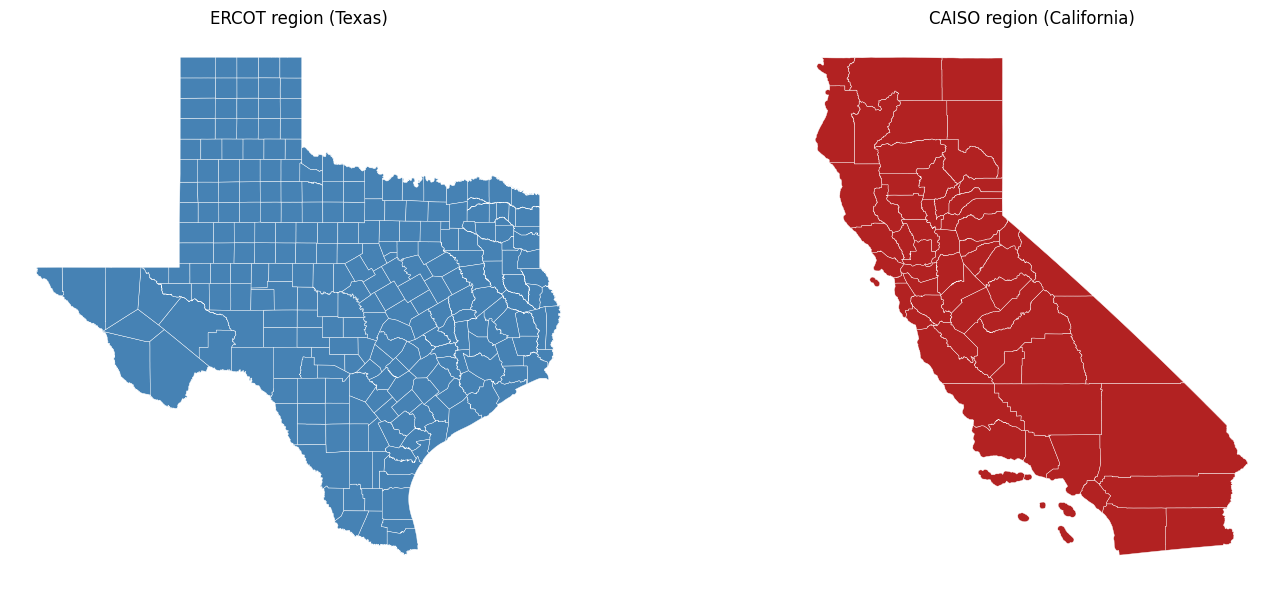

In [4]:
if ercot_gdf is not None and caiso_gdf is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    ercot_gdf.plot(ax=axes[0], color='steelblue', edgecolor='white', linewidth=0.3)
    axes[0].set_title('ERCOT region (Texas)')
    axes[0].axis('off')
    caiso_gdf.plot(ax=axes[1], color='firebrick', edgecolor='white', linewidth=0.3)
    axes[1].set_title('CAISO region (California)')
    axes[1].axis('off')
    plt.tight_layout()
    plt.savefig('../data/processed/study_area_maps.png', dpi=150, bbox_inches='tight')
    plt.show()


## 1.3 Verify FIPS completeness

In [5]:
if ercot_gdf is not None:
    missing_ercot = set(ERCOT_FIPS) - set(ercot_gdf['fips'])
    missing_caiso = set(CAISO_FIPS) - set(caiso_gdf['fips'])
    print('Missing ERCOT FIPS:', missing_ercot or 'None')
    print('Missing CAISO FIPS:', missing_caiso or 'None')


Missing ERCOT FIPS: None
Missing CAISO FIPS: None
